In [2]:
import sympy as sp
from sympy import series
import numpy as np
from importlib import reload  # Python 3.4+
import ISSWlib as IS; reload(IS)
import matplotlib.pyplot as plt
%matplotlib inline

### Symbolic manipulations
Symbol "f" here was formerly designated as $\tau'$.

In [46]:
R1R2, chi = sp.symbols('R1R2 chi')
top = (1-R1R2)*sp.exp(chi)+sp.sqrt((1-R1R2)**2*sp.exp(2*chi)+4*R1R2)
f = 1/2*sp.log(top/2)    
fp = sp.diff(f,chi,1)
fpp = sp.diff(f,chi,2)

print('f = ', f, '\n')
print('fp = ', fp, '\n')
print('fpp = ', fpp, '\n')
# sp.pprint(f)
# sp.pprint(fp)
# sp.pprint(fpp)

f_taylor = series(f, chi, 0, 2)
print('\nf ~ ', f_taylor)
fp_taylor = sp.diff(f_taylor,chi,1)
B_taylor = fp_taylor.subs(chi,0)
print('\nB ~ ', B_taylor)
sp.pprint(B_taylor)

B = fp.subs(chi,0)
print('\nB ~ ', B)
sp.pprint(B)

print(B_taylor.subs(R1R2,.5))
print(B.subs(R1R2,.5))

piece1 = sp.sqrt(4*R1R2 + (1 - R1R2)**2)
piece2 = 1+R1R2
B_taylor = B_taylor.subs(piece1,piece2)
B = B.subs(piece1,piece2)
sp.pprint(B_taylor)
sp.pprint(B)

B_simple = 1/2*(1-R1R2)/(1+R1R2)
B_simple = B_simple.factor()
sp.pprint(B_simple)

R1R2_num = 0.5
print(B.subs(R1R2,R1R2_num))
print(B_taylor.subs(R1R2,R1R2_num))
print(B_simple.subs(R1R2,R1R2_num))

f =  0.5*log((1 - R1R2)*exp(chi)/2 + sqrt(4*R1R2 + (1 - R1R2)**2*exp(2*chi))/2) 

fp =  0.5*((1 - R1R2)**2*exp(2*chi)/(2*sqrt(4*R1R2 + (1 - R1R2)**2*exp(2*chi))) + (1 - R1R2)*exp(chi)/2)/((1 - R1R2)*exp(chi)/2 + sqrt(4*R1R2 + (1 - R1R2)**2*exp(2*chi))/2) 

fpp =  0.5*(R1R2 - 1)*((R1R2 - 1)**3*exp(3*chi)/(4*R1R2 + (R1R2 - 1)**2*exp(2*chi))**(3/2) - (R1R2 - 1)*((R1R2 - 1)*exp(chi)/sqrt(4*R1R2 + (R1R2 - 1)**2*exp(2*chi)) - 1)**2*exp(chi)/((R1R2 - 1)*exp(chi) - sqrt(4*R1R2 + (R1R2 - 1)**2*exp(2*chi))) - 2*(R1R2 - 1)*exp(chi)/sqrt(4*R1R2 + (R1R2 - 1)**2*exp(2*chi)) + 1)*exp(chi)/((R1R2 - 1)*exp(chi) - sqrt(4*R1R2 + (R1R2 - 1)**2*exp(2*chi))) 


f ~  0.5*log(-R1R2/2 + sqrt(R1R2**2 + 2*R1R2 + 1)/2 + 1/2) + 0.5*chi*(R1R2**2 - R1R2*sqrt(R1R2**2 + 2*R1R2 + 1) - 2*R1R2 + sqrt(R1R2**2 + 2*R1R2 + 1) + 1)/(R1R2**2 - R1R2*sqrt(R1R2**2 + 2*R1R2 + 1) + 2*R1R2 + sqrt(R1R2**2 + 2*R1R2 + 1) + 1) + O(chi**2)

B ~  0.5*(R1R2**2 - R1R2*sqrt(R1R2**2 + 2*R1R2 + 1) - 2*R1R2 + sqrt(R1R2**2 + 2*R1R2 + 1) + 1)/(R1

### Numerical tests

AAE of this standard =  -0.5
beta2 from AAE =  11.547005383792515
(6,)
6
f_range_450 =  [0.06666667 0.16666667 0.33333333 0.83333333 1.33333333 2.2       ]
f_range_600 =  [0.07698004 0.19245009 0.38490018 0.96225045 1.53960072 2.54034118]
chi_range_450 =  [0.34365233 0.72981345 1.21848232 2.34181585 3.35739695 5.09307181]
chi_range_600 =  [0.4886729  0.97565008 1.54834508 2.82792866 3.99422198 5.99694992]
chi_range_450 =  [0.34422817 0.73208977 1.22163961 2.34381898 3.35401635 5.09039892]
chi_range_600 =  [0.4874636  0.98091833 1.54811424 2.82479851 3.99408957 5.9941351 ]


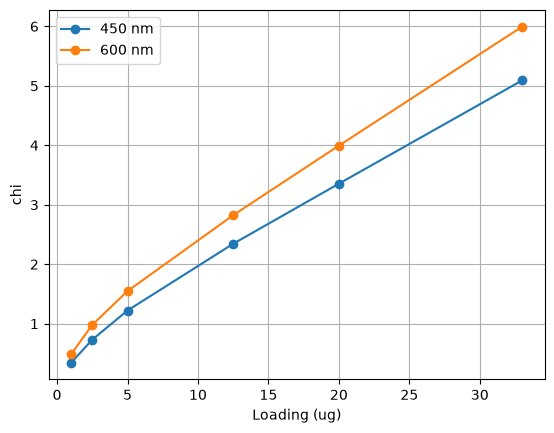

In [6]:
# Optical constants for BC
# beta1 = 8.9 # This is in m^2/g, for 450
# AAE_std = 1.09; print('AAE of this standard = ', AAE_std)
# beta2 = beta1 * (450/600)**AAE_std; print('beta2 from AAE = ', beta2)
beta1 = 10 # This is in m^2/g, for 450
AAE_std = -0.5; print('AAE of this standard = ', AAE_std)
beta2 = beta1 * (450/600)**AAE_std; print('beta2 from AAE = ', beta2)

# Loading values on samples and their optical depths
L_range = np.array([2, 5, 10, 25, 40, 66])/2 # This is in micrograms
print(np.shape(L_range))
tau_range_450 = L_range*beta1/100
tau_range_600 = L_range*beta2/100
N_L_range = np.size(L_range); print(N_L_range)

# Assumed values of R1R2
R1R2_450 = 0.5
R1R2_600 = 0.6

# Assumed valueas of kappa
kappa_450 = 1.5
kappa_600 = 1.5

# f-values (formerly designated as tau')
f_range_450 = tau_range_450 / kappa_450; print('f_range_450 = ', f_range_450)
f_range_600 = tau_range_600 / kappa_600; print('f_range_600 = ', f_range_600)

# Simulating ISSW absorption optical depths
chi_range_450 = IS.get_chi_theory(f_range_450,R1R2_450); print('chi_range_450 = ', chi_range_450)
chi_range_600 = IS.get_chi_theory(f_range_600,R1R2_600); print('chi_range_600 = ', chi_range_600)

# Adding noise to the simulated ISSW absorption optical depths
noiselevel = 0.002
noise = np.random.normal(0,noiselevel,N_L_range); #print(noise)
chi_range_450 += noise; print('chi_range_450 = ', chi_range_450)
noise = np.random.normal(0,noiselevel,N_L_range); #print(noise)
chi_range_600 += noise; print('chi_range_600 = ', chi_range_600)

plt.figure()
# plt.plot(chi_range_450,L_range,marker='o',label='450 nm')
# plt.plot(chi_range_600,L_range,marker='o',label='600 nm')
# plt.xlabel('chi')
# plt.ylabel('Loading')

plt.plot(L_range,chi_range_450,marker='o',label='450 nm')
plt.plot(L_range,chi_range_600,marker='o',label='600 nm')
plt.xlabel('Loading (ug)')
plt.ylabel('chi')

plt.legend()
plt.grid(True)

In [7]:
# Testing the AAE
f_range_450_obs = IS.invert_chi_theory(chi_range_450,R1R2_450)
f_range_600_obs = IS.invert_chi_theory(chi_range_600,R1R2_600)
bot = np.log(450/600)

for i in range(N_L_range):
    top = np.log(f_range_450_obs[i]*kappa_450/(f_range_600_obs[i]*kappa_600))
    AAE = -top/bot
    top_without_kappas = np.log(f_range_450_obs[i]/(f_range_600_obs[i]))
    AAE_without_kappas = -top_without_kappas/bot
    print(i,AAE,AAE_without_kappas)

0 -0.4827041872194015 -0.4827041872194015
1 -0.5128092245119427 -0.5128092245119427
2 -0.4865816571233194 -0.4865816571233194
3 -0.4904557212192806 -0.4904557212192806
4 -0.5042390692948097 -0.5042390692948097
5 -0.500185680879522 -0.500185680879522


### Now for a determination of R1R2 and kappa based on these simulated chi-values 

In [8]:
# Simulating deviations of R1R2 from the correct values

print('\nAt 450 nm ...')
delta_R1R2_450_start = -0.06; R1R2_450_start = R1R2_450 + delta_R1R2_450_start
print('starting with R1R2 = ', R1R2_450_start, 'and noise =', noiselevel)
R1R2_450, kappa_450 = IS.get_R1R2_and_kappa(chi_range_450,tau_range_450,R1R2_450_start)
print('I get R1R2, kappa = ', R1R2_450, kappa_450) 

print('\nAt 600 nm ...')
delta_R1R2_600_start = 0.04; R1R2_600_start = R1R2_600 + delta_R1R2_600_start
print('starting with R1R2 = ', R1R2_600_start, 'and noise =', noiselevel)
R1R2_600, kappa_600 = IS.get_R1R2_and_kappa(chi_range_600,tau_range_600,R1R2_600_start)
print('I get R2R2, kappa = ', R1R2_600, kappa_600) 


At 450 nm ...
starting with R1R2 =  0.44 and noise = 0.002
I get R1R2, kappa =  0.5028960614122296 1.5035855135015133

At 600 nm ...
starting with R1R2 =  0.64 and noise = 0.002
I get R2R2, kappa =  0.6001072820355768 1.5008025180345093
